In [8]:
import pandas as pd
import numpy as np

import seaborn as sns

In [7]:
# Generating random dataṣ

np.random.seed(20)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['Feature1','Feature2','Feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['Feature1','Feature2','Feature3'])
df1['target'] = 0

df = pd.concat([df,df1], ignore_index=True)

df = df.sample(40)

In [13]:
df.head()

,Feature1,Feature2,Feature3,target
17,-2.704365,-0.555186,0.001509,1
39,1.831106,0.634943,1.496770,0
28,0.590429,2.447407,0.595466,0
16,1.204511,1.351796,0.493437,1
2,0.939469,-0.978481,0.503097,1


<Axes: ylabel='Frequency'>

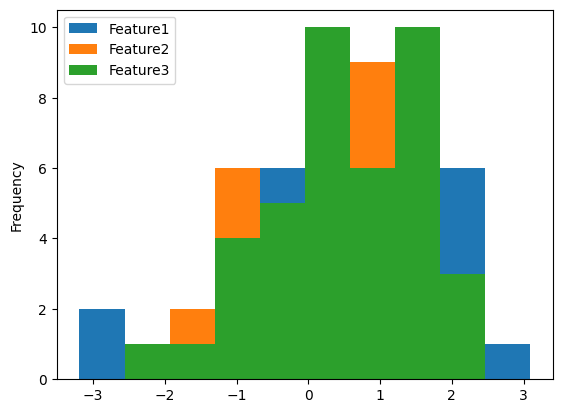

In [26]:
df.iloc[:,0:3].plot(kind='hist')

In [28]:
import plotly.express as px

In [32]:
fig = px.scatter_3d(
    df,
    x='Feature1',
    y='Feature2',
    z='Feature3',
    color='target'
)

fig.update_traces(
    marker=dict(size=12, line=dict(width=2, color='DarkSlateGrey')),
    selector=dict(mode='markers')
)

fig.show()

In [34]:
# Step 1 - Standard Scaler

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [ ]:
# Step 2 - covariance matrix

covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])

covariance_matrix

array([[ 1.02564103,  0.20213544, -0.01339227],
       [ 0.20213544,  1.02564103,  0.26596897],
       [-0.01339227,  0.26596897,  1.02564103]])

In [36]:
# Step 3 - eigen vactors , eigen values

eigen_val, eigen_vec = np.linalg.eig(covariance_matrix)

In [38]:
eigen_vec

array([[ 0.43773393, -0.79636897,  0.41735533],
       [-0.70020894, -0.01076545,  0.71385681],
       [ 0.56400039,  0.60471528,  0.56233708]])

In [37]:
eigen_val

array([0.68504534, 1.03854282, 1.35333492])

In [40]:
pc = eigen_vec[0:2]
pc

array([[ 0.43773393, -0.79636897,  0.41735533],
       [-0.70020894, -0.01076545,  0.71385681]])

In [42]:
# Tranforming from 3d to 2d

transformed_df = np.dot(df.iloc[:,0:3],pc.T)
#                       (40,3) - (2,3) -> T = (3,2)
#                       (40,3) . (3,2) -> (40,2)


new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values

new_df.head()

,PC1,PC2,target
0,-0.504983,1.292090,1
1,0.580449,-0.030650,0
2,-1.615367,-0.022749,0
3,-0.585578,-0.392946,1
4,1.192451,-0.226046,1


In [43]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(
  x = new_df['PC1'],
  y = new_df['PC2'],
  color = new_df['target'],
  color_discrete_sequence = px.colors.qualitative.G10
)

fig.update_traces(
  marker = dict(
    size=12,
    line=dict(
      width=2,
      color='DarkSlateGrey'
    )
  ),
  selector = dict(mode = 'markers')
)

fig.show()